<a href="https://colab.research.google.com/github/mariaaapetrovskaya/complingua/blob/main/28_02_rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
550378/550378 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Общая длина текста (символов): 399645
Размер словаря (кол уникальных символов): 39


/tmp/ipython-input-1389/3389792750.py:40: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)


Форма input_seq: torch.Size([399545, 100]), target_seq: torch.Size([399545])
Используется устройство: cuda

Эксперимент A: hidden_size=64, num_layers=1, lr=0.01
Эпоха 1, Loss: 1.8506
Эпоха 2, Loss: 1.7452
Эпоха 3, Loss: 1.7403
Эпоха 4, Loss: 1.7501
Время обучения: 149.33 сек
Сгенерированный текст:
the company and flour this 17 000 cts net intarational doment had may manuited op o profit withaness gainlan a state brited u s and and gres said shr 100 pct bill 10 500 pct to profit on dlrs and the said per for


Эксперимент B: hidden_size=256, num_layers=2, lr=0.001
Эпоха 1, Loss: 1.5669
Эпоха 2, Loss: 1.2855
Эпоха 3, Loss: 1.2204
Эпоха 4, Loss: 1.1876
Время обучения: 540.48 сек
Сгенерированный текст:
the company said that statement under it was hedtern in broke significantly is beet in support the company said it has also said roll the statement negotiations to the made the plin of largely to gold must set an


Эксперимент C: hidden_size=128, num_layers=2, lr=0.005
Эпоха 1, Loss: 1.7188
Э

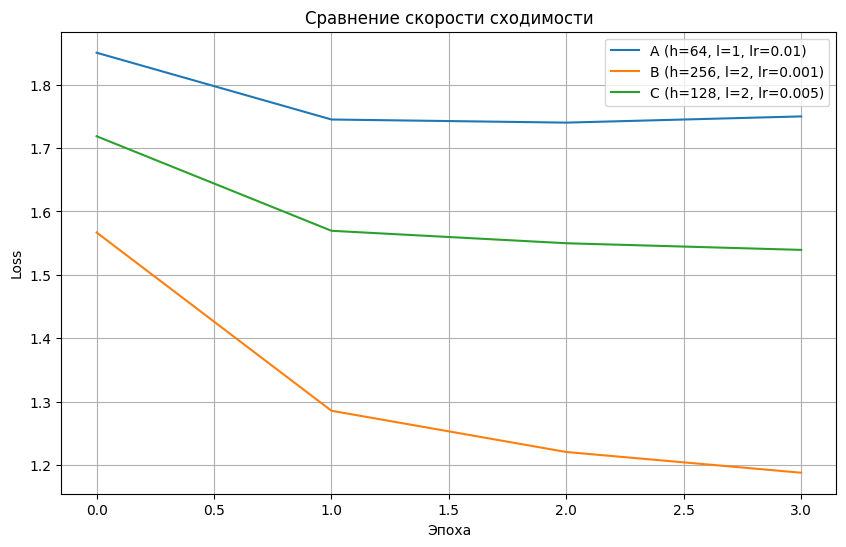


Сводная табл
Эксп  hidden   layers   lr         Время (с)  Loss финал
------------------------------------------------------------
A     64       1        0.01       149.33     1.7501    
B     256      2        0.001      540.48     1.1876    
C     128      2        0.005      191.28     1.5394    

Сгенерированные тексты (seed: 'the company ')

Эксперимент A
the company and flour this 17 000 cts net intarational doment had may manuited op o profit withaness gainlan a state brited u s and and gres said shr 100 pct bill 10 500 pct to profit on dlrs and the said per for

Эксперимент B
the company said that statement under it was hedtern in broke significantly is beet in support the company said it has also said roll the statement negotiations to the made the plin of largely to gold must set an

Эксперимент C
the company increase is work said the with added and heady pringing than commonweated to price record 11 5 mln stg ressicase financial acchitoly on the been and same achicated of 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters
from collections import Counter
import time

(x_train, y_train), (x_test, y_test) = reuters.load_data()
word_index = reuters.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

def decode_sequence(sequence):
    return ' '.join([reverse_word_index.get(i-3, '?') for i in sequence])

max_articles = 500
max_articles_idx = x_train[:max_articles]
max_articles_texts = [decode_sequence(seq) for seq in max_articles_idx]
texts = ' '.join(max_articles_texts)
print(f"Общая длина текста (символов): {len(texts)}")

chars = sorted(list(set(texts)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}
vocab_size = len(chars)
print(f"Размер словаря (кол уникальных символов): {vocab_size}")

text_as_int = [char_to_idx[ch] for ch in texts]
text_as_int = np.array(text_as_int)

seq_length = 100

def create_sequences(text_indices, seq_len):
    input_seq = []
    target_seq = []
    for i in range(len(text_indices)-seq_len):
        input_seq.append(text_indices[i:i+seq_len])
        target_seq.append(text_indices[i+seq_len])
    return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)

input_seq, target_seq = create_sequences(text_as_int, seq_length)
print(f"Форма input_seq: {input_seq.shape}, target_seq: {target_seq.shape}")

batch_size = 32
dataset = torch.utils.data.TensorDataset(input_seq, target_seq)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, embedding_dim=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        if hidden is None:
            lstm_out, hidden = self.lstm(embedded)
        else:
            lstm_out, hidden = self.lstm(embedded, hidden)

        lstm_out = lstm_out[:, -1, :]
        output = self.fc(lstm_out)
        return output, hidden


def generate_text(model, seed_text, length=200, temperature=1.0, device='cpu'):
    model.eval()
    generated = seed_text


    seed_indices = []
    for ch in seed_text:
        if ch in char_to_idx:
            seed_indices.append(char_to_idx[ch])
        else:
            seed_indices.append(0)

    with torch.no_grad():
        h = torch.zeros(model.num_layers, 1, model.hidden_size).to(device)
        c = torch.zeros(model.num_layers, 1, model.hidden_size).to(device)
        hidden = (h, c)


        for i in range(len(seed_indices) - 1):
            inp = torch.tensor([[seed_indices[i]]], dtype=torch.long).to(device)
            _, hidden = model(inp, hidden)


        current = torch.tensor([[seed_indices[-1]]], dtype=torch.long).to(device)
        for _ in range(length):
            output, hidden = model(current, hidden)
            output = output / temperature
            probs = torch.softmax(output, dim=-1)
            next_char_idx = torch.multinomial(probs, 1).item()
            generated += idx_to_char[next_char_idx]
            current = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)

    return generated


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")


experiments = {
    'A': {'hidden_size': 64, 'num_layers': 1, 'lr': 0.01},
    'B': {'hidden_size': 256, 'num_layers': 2, 'lr': 0.001},
    'C': {'hidden_size': 128, 'num_layers': 2, 'lr': 0.005}
}

EPOCHS = 4
results = {}

for name, params in experiments.items():
    print(f"\nЭксперимент {name}: hidden_size={params['hidden_size']}, num_layers={params['num_layers']}, lr={params['lr']}")

    model = CharLSTM(
        vocab_size=vocab_size,
        hidden_size=params['hidden_size'],
        num_layers=params['num_layers'],
        embedding_dim=64
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=params['lr'])

    train_losses = []
    start_time = time.time()

    for epoch in range(1, EPOCHS+1):
        model.train()
        total_loss = 0
        for batch_input, batch_target in dataloader:
            batch_input = batch_input.to(device)
            batch_target = batch_target.to(device)

            optimizer.zero_grad()
            output, _ = model(batch_input)
            loss = criterion(output, batch_target)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        train_losses.append(avg_loss)
        print(f"Эпоха {epoch}, Loss: {avg_loss:.4f}")

    end_time = time.time()
    training_time = end_time - start_time

    seed = "the company "
    generated = generate_text(model, seed, length=200, temperature=0.8, device=device)


    results[name] = {
        'losses': train_losses,
        'time': training_time,
        'generated': generated
    }

    print(f"Время обучения: {training_time:.2f} сек")
    print(f"Сгенерированный текст:\n{generated}\n")


plt.figure(figsize=(10, 6))
for name, res in results.items():
    plt.plot(res['losses'], label=f"{name} (h={experiments[name]['hidden_size']}, l={experiments[name]['num_layers']}, lr={experiments[name]['lr']})")
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Сравнение скорости сходимости')
plt.legend()
plt.grid(True)
plt.show()

print("\nСводная табл")
print(f"{'Эксп':<5} {'hidden':<8} {'layers':<8} {'lr':<10} {'Время (с)':<10} {'Loss финал':<10}")
print("-" * 60)
for name, res in results.items():
    p = experiments[name]
    print(f"{name:<5} {p['hidden_size']:<8} {p['num_layers']:<8} {p['lr']:<10} {res['time']:<10.2f} {res['losses'][-1]:<10.4f}")

print("\nСгенерированные тексты (seed: 'the company ')")
for name, res in results.items():
    print(f"\nЭксперимент {name}")
    print(res['generated'])

1. График loss:
Эксперимент A (hidden_size=64, num_layers=1, lr=0.01) показывает самое маленькое снижение loss. После первой эпохи значение падает с 1.8506 до 1.7452. Потом практически такой же (на 3 эпохе loss 1.7403, а к 4 немного возрастает до 1.7501. Модель недостаточно емкая, не может дальше обучаться.
Эксперимент B (hidden_size=256, num_layers=2, lr=0.001) хорошая сходимость. Loss последовательно снижается с 1.5669 до 1.1876.  На графике крутой наклон. Можно предположить что при большем кол-ве эпох еще больше улучшится.
Эксперимент C (hidden_size=128, num_layers=2, lr=0.005) между A и B. После первого эпохи loss падает с 1.7188 до 1.5695, потом замедляется: 1.5499 и 1.5394. Неплохо обучается, но B лучше.


---


2. Качество генерации текста
Все три текста сгенерированы с одним и тем же началом "the company " и одинаковой температурой 0.8. Р
В эксперименте A поток бессвязных грамм некорректных слов:
"the company and flour this 17 000 cts net intarational doment had may manuited op o profit withaness gainlan a state brited u s and and gres said shr 100 pct bill 10 500 pct to profit on dlrs and the said per for"
Эксперимент B:
"the company said that statement under it was hedtern in broke significantly is beet in support the company said it has also said roll the statement negotiations to the made the plin of largely to gold must set an"
Есть опечатки. Но грамм структура видна, лексика определенной сферы (statement, negotiations, support). Можно понять общий смысл.
Эксперимент C:
"the company increase is work said the with added and heady pringing than commonweated to price record 11 5 mln stg ressicase financial acchitoly on the been and same achicated of terman include consider that whic"
Есть понятные слова и элементы, но много непонятных слов, искажений. Связность текста средняя.


---


3. Время обучения
Модель A обучилась за 149 секунд
Модель B 540 секунд (много параметров)
Модель C 191 секунда


Какие ключевые отличия вы заметили в подготовке данных для числового ряда (синусоида) и текста?
Для текста данные дискретны (преобр индексов, эмбединг), для синусоиды - непрерывные числа.

Какой опыт работы с PyTorch (например, отладка, подбор параметров) оказался самым полезным? Сам эксперимент с гиперпараметрами, как емкость модели зависит, генерация текста